# Proj4 - CS484 Project on topic 4

course name: CS484  
name: Yuanhao Liu (Jim Liu)  
uw email: y2544liu@uwaterloo.ca  
quest id: y2544liu  

## Abstract

This project extends the a4 interactive segmentation framework by replacing low-level color features with deep features from a pretrained DINO ViT-S/8 model. The baseline framework uses seed-based s/t graph cuts — user-placed foreground and background seeds enforce hard t-link constraints, while pairwise smoothness n-links weighted by RGB color contrast regularize the boundary. The motivation for using deep features is that raw color contrast fails in regions where foreground and background share similar color distributions, and semantic-level embeddings are expected to provide stronger feature separation in these cases.

Three variants are evaluated on two test images (bunny and lama): raw RGB color baseline (sub1.1), GMM color likelihood as t-link priors (sub1.2), and DINO patch features replacing n-link weights via PCA reduction to 16 dimensions. Results show that GMM improved over the raw color baseline, while DINO deep feature substitution degraded segmentation quality below both baselines — pointing to a structural mismatch between DINO feature geometry and n-link L2 weighting assumptions. Conclusions discuss this failure and propose a rectification using DINO attention maps as t-link priors instead.

## Code Libraries

**PyMaxflow** — computes minimum s/t graph cuts on weighted grid graphs; provides `add_grid_nodes`, `add_grid_edges`, `add_grid_tedges`, and `maxflow` used throughout all three segmentation variants.

**scikit-learn (sklearn.mixture.GaussianMixture, sklearn.decomposition.PCA)** — `GaussianMixture` estimates per-segment color distributions from user seeds for GMM t-link weights; `PCA` reduces DINO patch features from 384 to 16 dimensions to make n-link computation tractable.

**PyTorch (torch, torch.nn.functional)** — loads and runs the pretrained DINO ViT-S/8 model; used for patch feature extraction via `get_intermediate_layers` and bilinear upsampling via `F.interpolate`.

**torchvision (torchvision.transforms)** — handles image normalization to ImageNet mean/std before passing to DINO; required for correct pretrained feature extraction.

**asg1_error_handling** (custom module) — provides `GraphCutsPresenter` GUI for interactive seed placement and `Figure` canvas wrapper; carries over directly from a4 scaffold.

**version**:  

python: 3.12.10 (tags/v3.12.10:0cc8128, Apr  8 2025, 12:21:36) [MSC v.1943 64 bit (AMD64)]  
torch: 2.5.1+cu121 | torchvision: 0.20.1+cu121  
maxflow: 1.3.2  
sklearn: 1.8.0  
numpy: 2.4.2  
matplotlib: 3.10.8  

In [1]:
%matplotlib widget
import numpy as np
import matplotlib.pyplot as plt

# loading standard library for GMM estimation
from sklearn import mixture

# loading standard maxflow library (graph cuts)
# Before importing maxflow first time, you must "pip install PyMaxflow" in Anaconda Prompt (see https://pypi.org/project/PyMaxflow/) 
import maxflow

# loading custom module (requires file asg1.py in the same directory as the notebook file)
from asg1_error_handling import Figure, GraphCutsPresenter

In [2]:
#A1
import torch
import torch.nn.functional as F
import torchvision.transforms as T

model = torch.hub.load('facebookresearch/dino:main', 'dino_vits8')
model.eval()





Using cache found in C:\Users\lawcr/.cache\torch\hub\facebookresearch_dino_main


VisionTransformer(
  (patch_embed): PatchEmbed(
    (proj): Conv2d(3, 384, kernel_size=(8, 8), stride=(8, 8))
  )
  (pos_drop): Dropout(p=0.0, inplace=False)
  (blocks): ModuleList(
    (0-11): 12 x Block(
      (norm1): LayerNorm((384,), eps=1e-06, elementwise_affine=True)
      (attn): Attention(
        (qkv): Linear(in_features=384, out_features=1152, bias=True)
        (attn_drop): Dropout(p=0.0, inplace=False)
        (proj): Linear(in_features=384, out_features=384, bias=True)
        (proj_drop): Dropout(p=0.0, inplace=False)
      )
      (drop_path): Identity()
      (norm2): LayerNorm((384,), eps=1e-06, elementwise_affine=True)
      (mlp): Mlp(
        (fc1): Linear(in_features=384, out_features=1536, bias=True)
        (act): GELU(approximate='none')
        (fc2): Linear(in_features=1536, out_features=384, bias=True)
        (drop): Dropout(p=0.0, inplace=False)
      )
    )
  )
  (norm): LayerNorm((384,), eps=1e-06, elementwise_affine=True)
  (head): Identity()
)

In [3]:
#A2

def extract_dino_features(img_np):
    img_np = img_np.copy()
    H, W = img_np.shape[:2]
    # pad to multiple of patch size 8
    H_pad = ((H + 7) // 8) * 8
    W_pad = ((W + 7) // 8) * 8

    transform = T.Compose([
        T.ToTensor(),
        T.Normalize(mean=[0.485, 0.456, 0.406],
                    std=[0.229, 0.224, 0.225]),
    ])
    img_t = transform(img_np).unsqueeze(0)
    img_t = F.pad(img_t, (0, W_pad - W, 0, H_pad - H))

    with torch.no_grad():
        feat = model.get_intermediate_layers(img_t, n=1)[0]

    # drop CLS token, keep patch tokens only
    feat = feat[:, 1:, :]
    h_p, w_p = H_pad // 8, W_pad // 8
    feat = feat.reshape(1, h_p, w_p, 384).permute(0, 3, 1, 2)
    # upsample patch features to full image resolution
    feat = F.interpolate(feat, size=(H, W),
                         mode='bilinear', align_corners=False)
    feat = feat.squeeze(0).permute(1, 2, 0).numpy()
    return feat  # shape: H x W x 384


def extract_dino_attention(img_np):
    H, W = img_np.shape[:2]
    H_pad = ((H + 7) // 8) * 8
    W_pad = ((W + 7) // 8) * 8

    transform = T.Compose([
        T.ToTensor(),
        T.Normalize(mean=[0.485, 0.456, 0.406],
                    std=[0.229, 0.224, 0.225]),
    ])
    img_np = img_np.copy()
    img_t = transform(img_np).unsqueeze(0)
    img_t = F.pad(img_t, (0, W_pad - W, 0, H_pad - H))

    with torch.no_grad():
        attn = model.get_last_selfattention(img_t)

    # CLS-to-patch attention averaged across heads
    attn = attn[:, :, 0, 1:]
    attn = attn.mean(dim=1)
    h_p, w_p = H_pad // 8, W_pad // 8
    attn = attn.reshape(1, 1, h_p, w_p)
    # upsample attention map to full image resolution
    attn = F.interpolate(attn, size=(H, W),
                         mode='bilinear', align_corners=False)
    attn_map = attn.squeeze().numpy()
    return attn_map

In [4]:
# package version check

import sys
print("python:", sys.version)

try:
    import torch, torchvision
    print("torch:", torch.__version__, "| torchvision:", torchvision.__version__)
except Exception as e:
    print("torch/torchvision import error:", e)

try:
    import maxflow
    print("maxflow:", maxflow.__version__)
except Exception as e:
    print("maxflow import error:", e)

try:
    import sklearn
    print("sklearn:", sklearn.__version__)
except Exception as e:
    print("sklearn import error:", e)

try:
    import numpy as np
    print("numpy:", np.__version__)
except Exception as e:
    print("numpy import error:", e)

try:
    import matplotlib
    print("matplotlib:", matplotlib.__version__)
except Exception as e:
    print("matplotlib import error:", e)

python: 3.12.10 (tags/v3.12.10:0cc8128, Apr  8 2025, 12:21:36) [MSC v.1943 64 bit (AMD64)]
torch: 2.5.1+cu121 | torchvision: 0.20.1+cu121
maxflow: 1.3.2
sklearn: 1.8.0
numpy: 2.4.2
matplotlib: 3.10.8


## Variant 1: Raw Color Baseline

Seed-based s/t graph cuts using RGB pixel contrast for n-link weights. Seeds enforce hard t-link constraints; pairwise smoothness regularizes the boundary via contrast-weighted n-links. This establishes the performance baseline for comparison with GMM and deep feature variants.

In [5]:
class MyGraphCuts:
    bgr_value = 0
    obj_value = 1
    none_value = 2
    
    def __init__(self, img):
        self.fig = Figure()
        self.pres = GraphCutsPresenter(img, self)
        self.pres.connect_figure(self.fig)

        self.num_rows = img.shape[0]
        self.num_cols = img.shape[1]

    def run(self):
        self.fig.show()

    def compute_labels(self, seed_mask):
        num_rows = self.num_rows
        num_cols = self.num_cols

        # This initial version "works" by returning the following mask
        # +---------+---------+
        # |         |         |
        # |   bgr   |  none   |
        # |         |         |
        # +---------+---------+
        # |         |         |
        # |  none   |   obj   |
        # |         |         |
        # +---------+---------+
        # Replace with your code that computes the object and background mask based on the output of your graph cut implementation
        
        # get image data for n-link weights
        img = self.pres.img
        
        # graph cut parameters
        lambda_val = 50.0  # smoothness weight, tune this for different results
        sigma = 30.0       # color difference sensitivity

        
        # create graph with maxflow library
        import maxflow
        g = maxflow.Graph[float]()
        nodes = g.add_grid_nodes((num_rows, num_cols))
        
        # t-links: connect each pixel to source/sink based on seeds
        INF = 1e10
        for y in range(num_rows):
            for x in range(num_cols):
                node = nodes[y, x]
                if seed_mask[y, x] == self.obj_value:
                    # user marked foreground: must connect to source
                    g.add_tedge(node, INF, 0)
                elif seed_mask[y, x] == self.bgr_value:
                    # user marked background: must connect to sink
                    g.add_tedge(node, 0, INF)
                else:
                    # unlabeled pixel: no hard constraint
                    g.add_tedge(node, 0, 0)
        
        # n-links: connect neighboring pixels, weight by color similarity
        for y in range(num_rows):
            for x in range(num_cols):
                node = nodes[y, x]
                
                # right neighbor
                if x + 1 < num_cols:
                    diff = np.sum((img[y, x].astype(float) - img[y, x+1].astype(float))**2)
                    weight = lambda_val * np.exp(-diff / (2 * sigma**2))
                    g.add_edge(node, nodes[y, x+1], weight, weight)  # undirected
                
                # below neighbor
                if y + 1 < num_rows:
                    diff = np.sum((img[y, x].astype(float) - img[y+1, x].astype(float))**2)
                    weight = lambda_val * np.exp(-diff / (2 * sigma**2))
                    g.add_edge(node, nodes[y+1, x], weight, weight)  # undirected
        
        # run max-flow to get min-cut
        g.maxflow()
        
        # get segmentation: True = connected to source = foreground
        segments = g.get_grid_segments(nodes)
        
        # convert bool mask to label values
        label_mask = np.where(segments, self.obj_value, self.bgr_value).astype('uint8')
        
        return label_mask

    # sub1.2
    def compute_labels_gmm(self, seed_mask):
        num_rows = self.num_rows
        num_cols = self.num_cols
        img = self.pres.img

        lambda_val = 50.0
        sigma = 30.0
        eps = 1e-10

        # fit GMM on seed colors
        obj_pixels = img[seed_mask == self.obj_value].astype(float)
        bgr_pixels = img[seed_mask == self.bgr_value].astype(float)

        if len(obj_pixels) < 6 or len(bgr_pixels) < 6:
            return np.full((num_rows, num_cols), self.none_value, dtype='uint8')

        gmm_obj = mixture.GaussianMixture(n_components=6).fit(obj_pixels)
        gmm_bgr = mixture.GaussianMixture(n_components=6).fit(bgr_pixels)

        # NLL per pixel
        pixels_flat = img.reshape(-1, 3).astype(float)
        nll_obj = -np.log(np.exp(gmm_obj.score_samples(pixels_flat)) + eps).reshape(num_rows, num_cols)
        nll_bgr = -np.log(np.exp(gmm_bgr.score_samples(pixels_flat)) + eps).reshape(num_rows, num_cols)

        # build graph
        import maxflow
        g = maxflow.Graph[float]()
        nodes = g.add_grid_nodes((num_rows, num_cols))

        # t-links: NLL + hard seeds
        INF = 1e10
        t_source = nll_bgr.copy()
        t_sink   = nll_obj.copy()
        t_source[seed_mask == self.obj_value] = INF
        t_sink  [seed_mask == self.obj_value] = 0
        t_source[seed_mask == self.bgr_value] = 0
        t_sink  [seed_mask == self.bgr_value] = INF
        g.add_grid_tedges(nodes, t_source, t_sink)

        # n-links
        diff_right = np.sum((img[:, :-1].astype(float) - img[:, 1:].astype(float))**2, axis=2)
        diff_below = np.sum((img[:-1, :].astype(float) - img[1:, :].astype(float))**2, axis=2)
        n_right = np.zeros((num_rows, num_cols))
        n_below = np.zeros((num_rows, num_cols))
        n_right[:, :-1] = lambda_val * np.exp(-diff_right / (2 * sigma**2))
        n_below[:-1, :] = lambda_val * np.exp(-diff_below / (2 * sigma**2))
        structure_x = np.array([[0,0,0],[0,0,1],[0,0,0]])
        structure_y = np.array([[0,0,0],[0,0,0],[0,1,0]])
        g.add_grid_edges(nodes, weights=n_right, structure=structure_x, symmetric=True)
        g.add_grid_edges(nodes, weights=n_below, structure=structure_y, symmetric=True)

        g.maxflow()
        segments = g.get_grid_segments(nodes)
        return np.where(segments, self.obj_value, self.bgr_value).astype('uint8')

# stop here before run each branch pair

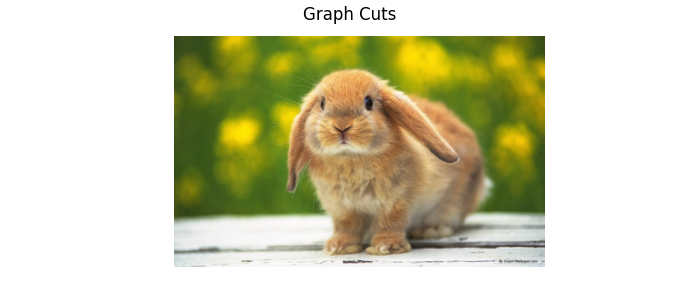

In [6]:
img1 = plt.imread('images/bunny.bmp')
app = MyGraphCuts(img1)
app.run()

#### Result - bunny image

![bunny result](demo/rabbit1.png)

Bunny Observation:  
lambda=50, sigma=30

- main body is separated from background, but some errors remain
- left side below left ear: background region incorrectly pulled into foreground
- near right foot: background patch incorrectly labeled as foreground
- right rear body: actual foreground region missed, labeled as background
- overall shape is roughly correct but boundary has local leakage around ambiguous fur edges

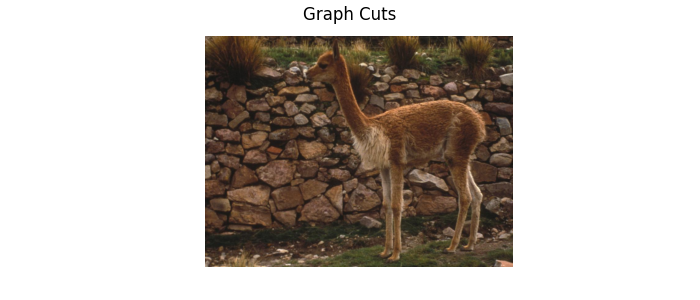

In [9]:
img2 = plt.imread('images/lama.jpg')
app = MyGraphCuts(img2)
app.run()

#### Result - lama image (challenging case)

![lama result](demo/ggref1.png)

Lama Observation (Bunny observation is above):  
lambda=50, sigma=30

- upper left body segmented reasonably well
- upper right body: white fluffy fur region not captured, similar color to background
- head boundary: actual foreground edges partially labeled as background
- lower body and legs: consistent difficulty — belly boundary and lower legs ambiguous due to color overlap with rock background
- baseline limitation: only seed hard constraints + pairwise smoothness, no per-pixel color evidence for ambiguous regions
- next comparison: GMM color likelihood and deep feature variants are expected to address color-overlap cases

lambda=0.01, sigma=30 (no regularization)

![lama lambda=0.01](demo/ggref1zerothirty.png)

- segmentation is conservative — blue region smaller than actual lama body
- neck region not captured, surrounding background incorrectly pulled into foreground
- without smoothness term, boundary only follows seed hard constraints
- lower body and legs still difficult, same color ambiguity issue as default

lambda=50, sigma=10

![lama sigma=10](demo/ggref1fiftyTen.png)

- upper body segmentation notably better — mouth and ear regions captured
- small sigma makes n-links sensitive to fine color differences, helps upper body detail
- lower belly boundary: background region near belly incorrectly labeled as foreground
- lower legs: actual foreground leg pixels labeled as background
- lower body and legs remain difficult, sigma=10 helps upper detail but not lower ambiguity

lambda=50, sigma=60

![lama sigma=60](demo/ggref1fiftySixty.png)

- head region: actual foreground edges conservatively labeled as background
- neck boundary: background region near neck incorrectly pulled into foreground
- large sigma makes n-links insensitive to color difference, smoothness dominates
- belly boundary and lower legs still difficult, over-smoothing spreads the boundary error

## Variant 2: GMM Color Likelihood

Extends Variant 1 by adding per-segment GMM color distributions as soft t-link priors — foreground and background color models are estimated from user seeds, and per-pixel negative log-likelihoods replace the hard seed-only t-links for unlabeled pixels. N-links remain RGB contrast-weighted as in Variant 1.

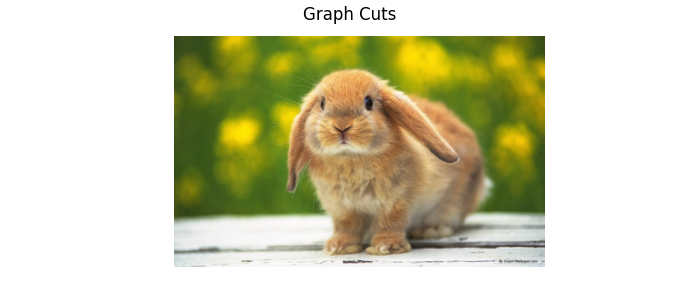

In [10]:
# note: if error occur,PLEASE MANUALLY try restart kernal+ rerun code until "# stop here before run each branch pair" 
# hen skip previous all app.run() block to directly run this branch pair MyGraphCutsGMM(img11) and MyGraphCutsGMM(img12)
# due to python tool function boundry

class MyGraphCutsGMM(MyGraphCuts):
    def compute_labels(self, seed_mask):
        return self.compute_labels_gmm(seed_mask)
img11 = plt.imread('images/bunny.bmp')
app = MyGraphCutsGMM(img11)
app.run()

#### Result - bunny image

![bunny result](demo/rabbit11.png)

Bunny Observation (sub-problem 1.2):  
lambda=50, sigma=30

- object mostly correctly segmented, boundary variation smaller than sub-problem 1.1
- white tail fur region not captured — similar color to background, GMM color term still struggles here
- overall outline error is small, no large region-level leakage

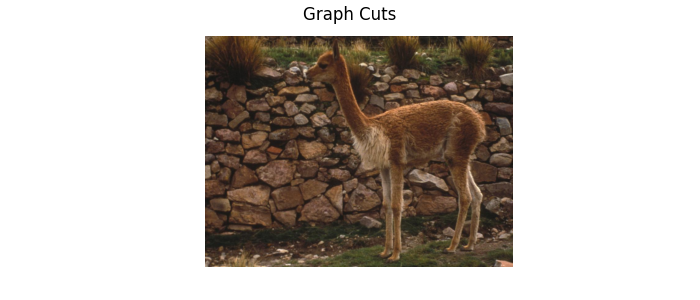

In [11]:
class MyGraphCutsGMM(MyGraphCuts):
    def compute_labels(self, seed_mask):
        return self.compute_labels_gmm(seed_mask)
img12 = plt.imread('images/lama.jpg')
app = MyGraphCutsGMM(img12)
app.run()

#### Result - lama image (challenging case)

![lama result](demo/ggref11B.png)

Lama Observation (sub-problem 1.2):  
lambda=50, sigma=30

- boundary variation significantly reduced compared to sub-problem 1.1
- head outline is more stable, though ear and mouth details still not captured
- upper body has minor errors but no large region-level leakage
- belly boundary and lower legs remain difficult — color overlap with background persists even with GMM color term
- overall improvement: GMM provides per-pixel color evidence that tightens the boundary, especially in upper body region

## Variant 3: DINO Deep Features

Replaces raw RGB pixel values with pretrained DINO ViT-S/8 patch embeddings as n-link features. Patch features (384-dim) are extracted via `get_intermediate_layers`, upsampled to full image resolution, and reduced to 16 dimensions via PCA before computing n-link L2 weights. T-link structure and seed mechanism remain unchanged from Variant 1.

In [6]:
#B1
from sklearn.decomposition import PCA

class MyGraphCutsDeep(MyGraphCuts):
    def __init__(self, img, feat):
        super().__init__(img)
        # reduce 384-dim patch features to 16 via PCA
        flat = feat.reshape(-1, feat.shape[-1])
        pca = PCA(n_components=16)
        reduced = pca.fit_transform(flat)
        self.feat = reduced.reshape(
            feat.shape[0], feat.shape[1], 16)
        # normalize to [0, 255] to match n-link sigma scale
        f = self.feat
        self.feat = (f - f.min()) / (f.max() - f.min() + 1e-8) * 255

    def compute_labels(self, seed_mask):
        # swap img with deep features for n-link weight computation
        img_orig = self.pres.img
        self.pres.img = self.feat
        result = super().compute_labels(seed_mask)
        self.pres.img = img_orig
        return result

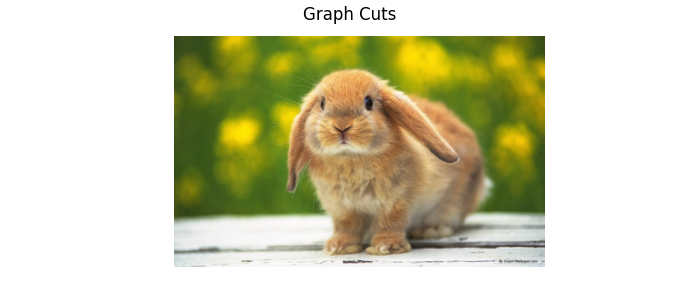

In [7]:
# note: if error occur, PLEASE MANUALLY try restart kernal+ rerun code until "# stop here before run each branch pair" 
# then skip previous all app.run() block to directly run from B1 to B5 to activate  MyGraphCutsDeep(img_d1, feat_d1) and MyGraphCutsDeep(img_d2, feat_d2) func
# due to python tool function boundry

#B2
img_d1 = plt.imread('images/bunny.bmp')
feat_d1 = extract_dino_features(img_d1)
app = MyGraphCutsDeep(img_d1, feat_d1)
app.run()

#B3
#### Result - bunny image (DINO deep features)

![bunny result](demo/dino_draft6_bunny.png)

Bunny Observation (DINO deep features, PCA 384→16):  
lambda=50, sigma=30

- right ear region: boundary roughly captured, partial foreground coverage
- main body interior: fragmented — alternating foreground/background patches across torso
- left body boundary: jagged edge, no smooth alignment with fur contour
- patch-level artifact: stride-8 DINO features introduce block-boundary jumps after bilinear upsample, producing intra-region cuts
- n-link weighting issue: L2 distance in PCA-reduced feature space does not encode local pixel contrast — n-link weights lose discriminative power near boundaries
- overall: segmentation quality below raw color baseline; deep feature replacement degrades n-link behavior rather than improving it

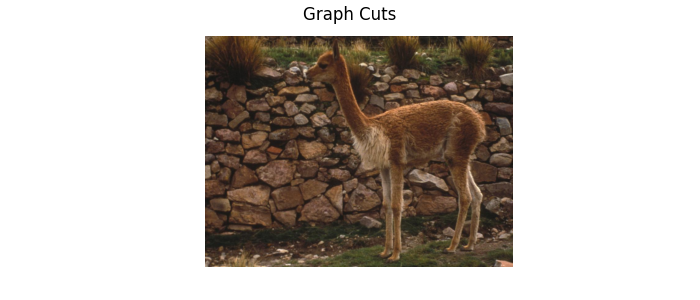

In [8]:
#B4
img_d2 = plt.imread('images/lama.jpg')
feat_d2 = extract_dino_features(img_d2)
app = MyGraphCutsDeep(img_d2, feat_d2)
app.run()

#B5
#### Result - lama image (DINO deep features)

![lama result](demo/dino_draft6_ggref.png)

Lama Observation (DINO deep features, PCA 384→16):  
lambda=50, sigma=30

- neck and upper chest: partial foreground coverage, boundary jagged
- upper right back: thin foreground strip captured, not stable
- head region: not captured — labeled as background throughout
- upper tail and rear: foreground region missed entirely
- lower legs: consistent difficulty — same color-overlap failure as raw color baseline, DINO features provide no improvement here
- coverage significantly below raw color baseline — regions ggref1 captured correctly (neck, main torso) are missed or fragmented here
- root cause: DINO features encode semantic embedding similarity, not local contrast — direct substitution into n-link L2 weighting is structurally mismatched; rectification would require using DINO attention maps as t-link priors rather than feature vectors as n-link weights

#B6

## Conclusions

This project implemented interactive image segmentation by replacing low-level color features in a seed-based s/t graph cut framework (a4) with deep features from a pretrained DINO ViT-S/8 model. Three variants were evaluated: raw RGB color with pairwise smoothness (sub1.1 baseline), GMM-based color likelihood replacing t-link weights (sub1.2), and DINO patch features replacing n-link weights via PCA reduction (proj4 extension).

The GMM variant consistently improved over the raw color baseline — boundary variation tightened and per-pixel color evidence reduced region-level leakage in upper body regions across both test images. However, color-overlap regions (lower legs, white fur against similar-toned background) remained difficult for both sub1.1 and sub1.2, since neither has access to semantic-level feature distinctions. The DINO deep feature variant performed below both baselines — segmentation coverage collapsed on the lama image (neck, torso, head largely missed), and internal fragmentation appeared on the bunny image. The root cause is a structural mismatch: DINO features encode semantic embedding similarity optimized for cosine distance, not local pixel contrast — substituting them directly into n-link L2 weighting degrades rather than improves boundary detection. PCA reduction to 16 dimensions and min-max normalization partially mitigated scale mismatch but did not resolve the fundamental misalignment between feature geometry and n-link assumptions.

A well-motivated rectification would decouple the two roles: use DINO self-attention maps (CLS-to-patch attention averaged across heads) as soft t-link priors — high attention weight biases a pixel toward foreground, low weight toward background — while retaining raw color contrast for n-link weights. This preserves the local contrast sensitivity of n-links and leverages DINO's semantic foreground localization through the t-link channel, where it is geometrically appropriate.